# aFRR Activation Rate Validation: Physical vs ML

This notebook compares two aFRR activation-rate definitions for **POS direction**:

- `activation_rate_phys_pos`: signed, uncapped physical ratio
- `activation_rate_ml_pos`: absolute, capped at 1.0 ML target

Data source: `data/processed/all_data_refined.parquet`.


In [1]:
import polars as pl
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
plt.rcParams['figure.figsize'] = (12, 6)

# Unified project plotting style
try:
    from energy_trading.visualization.style import apply_geo_style
except ModuleNotFoundError:
    import sys
    from pathlib import Path

    _root = Path.cwd().resolve()
    if _root.name == 'notebooks':
        _root = _root.parent
    _src = _root / 'src'
    if str(_src) not in sys.path:
        sys.path.insert(0, str(_src))
    from energy_trading.visualization.style import apply_geo_style

apply_geo_style()


In [2]:
# Robust path discovery (works from project root or notebooks/).
rel = Path("data/processed/all_data_refined.parquet")
search_roots = [Path.cwd(), *Path.cwd().parents]
DATA_PATH = None
for root in search_roots:
    cand = (root / rel).resolve()
    if cand.exists():
        DATA_PATH = cand
        break

if DATA_PATH is None:
    tried = "\n".join(str((r / rel).resolve()) for r in search_roots)
    raise FileNotFoundError("Could not find all_data_refined.parquet. Tried:\n" + tried)

print("Loaded:", DATA_PATH)

df = (
    pl.read_parquet(DATA_PATH)
    .with_columns(pl.col("timestamp_utc").cast(pl.Datetime(time_unit="us", time_zone="UTC"), strict=False))
    .sort("timestamp_utc")
)

required_cols = [
    "timestamp_utc",
    "activation_rate_phys_pos",
    "activation_rate_ml_pos",
    "afrr_capacity_awarded_mw_pos",
    "rz_saldo_mw",
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("Rows:", df.height)


Loaded: /Users/leori/Code/energyTrading/data/processed/all_data_refined.parquet
Rows: 44568


## 1) Descriptive Statistics & Distribution
We compute summary statistics and quantiles for both rate definitions.


In [3]:
stats = df.select([
    pl.col('activation_rate_phys_pos').cast(pl.Float64, strict=False).min().alias('phys_min'),
    pl.col('activation_rate_phys_pos').cast(pl.Float64, strict=False).max().alias('phys_max'),
    pl.col('activation_rate_phys_pos').cast(pl.Float64, strict=False).mean().alias('phys_mean'),
    pl.col('activation_rate_phys_pos').cast(pl.Float64, strict=False).median().alias('phys_median'),
    pl.col('activation_rate_phys_pos').cast(pl.Float64, strict=False).quantile(0.90).alias('phys_q90'),
    pl.col('activation_rate_phys_pos').cast(pl.Float64, strict=False).quantile(0.95).alias('phys_q95'),
    pl.col('activation_rate_phys_pos').cast(pl.Float64, strict=False).quantile(0.99).alias('phys_q99'),

    pl.col('activation_rate_ml_pos').cast(pl.Float64, strict=False).min().alias('ml_min'),
    pl.col('activation_rate_ml_pos').cast(pl.Float64, strict=False).max().alias('ml_max'),
    pl.col('activation_rate_ml_pos').cast(pl.Float64, strict=False).mean().alias('ml_mean'),
    pl.col('activation_rate_ml_pos').cast(pl.Float64, strict=False).median().alias('ml_median'),
    pl.col('activation_rate_ml_pos').cast(pl.Float64, strict=False).quantile(0.90).alias('ml_q90'),
    pl.col('activation_rate_ml_pos').cast(pl.Float64, strict=False).quantile(0.95).alias('ml_q95'),
    pl.col('activation_rate_ml_pos').cast(pl.Float64, strict=False).quantile(0.99).alias('ml_q99'),
])

stats


phys_min,phys_max,phys_mean,phys_median,phys_q90,phys_q95,phys_q99,ml_min,ml_max,ml_mean,ml_median,ml_q90,ml_q95,ml_q99
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.858523,0.015556,0.002559,0.040372,0.073526,0.19771,0.0,0.858523,0.015556,0.002559,0.040372,0.073526,0.19771


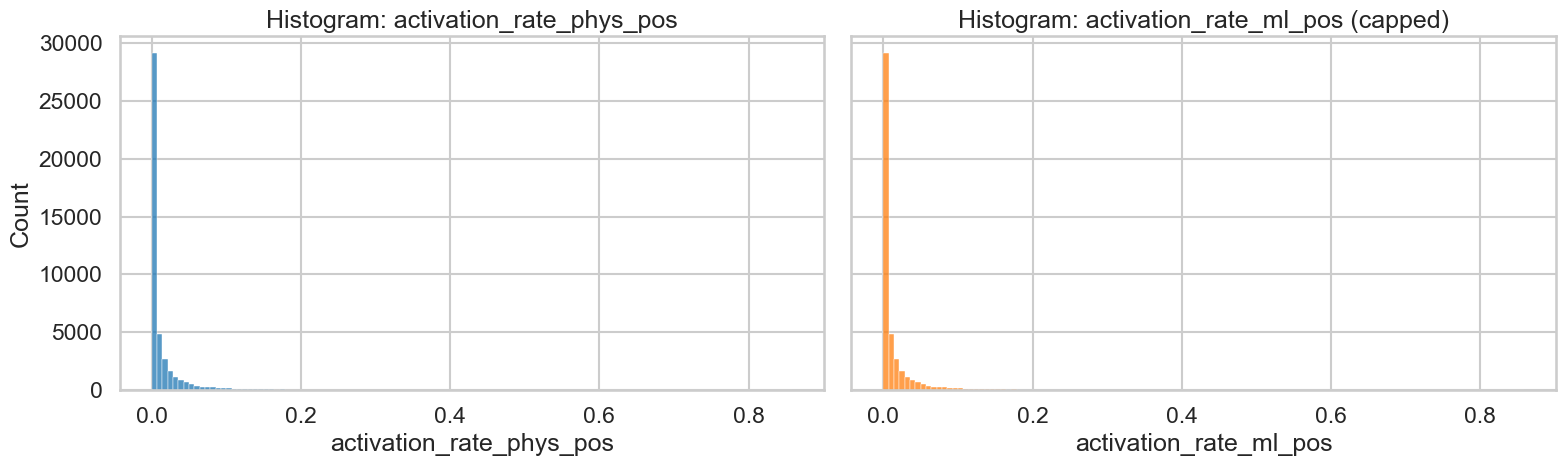

Rows exactly at ML cap (1.0): 0


In [4]:
pdf = df.select([
    pl.col('activation_rate_phys_pos').cast(pl.Float64, strict=False),
    pl.col('activation_rate_ml_pos').cast(pl.Float64, strict=False),
]).to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

sns.histplot(pdf['activation_rate_phys_pos'].dropna(), bins=120, ax=axes[0], color='#1f77b4')
axes[0].set_title('Histogram: activation_rate_phys_pos')
axes[0].set_xlabel('activation_rate_phys_pos')

sns.histplot(pdf['activation_rate_ml_pos'].dropna(), bins=120, ax=axes[1], color='#ff7f0e')
axes[1].set_title('Histogram: activation_rate_ml_pos (capped)')
axes[1].set_xlabel('activation_rate_ml_pos')

plt.tight_layout()
plt.show()

spike_at_one = (
    df
    .filter(pl.col('activation_rate_ml_pos').cast(pl.Float64, strict=False) == 1.0)
    .height
)
print('Rows exactly at ML cap (1.0):', spike_at_one)


**Conclusion (Section 1)**

The ML rate is expected to show a spike at **1.0** because all high-stress events are clipped to the cap. This improves target stability for sequence models but compresses tail information that exists in the physical rate.


## 2) Plausibility Tests & Stress Analysis

In [5]:
# Test A: Physical stress hours (>1.0)
stress_df = df.filter(pl.col('activation_rate_phys_pos').cast(pl.Float64, strict=False) > 1.0)
stress_count = stress_df.height
stress_share = stress_count / df.height if df.height else np.nan

print('Stress hours (phys > 1.0):', stress_count)
print('Share of all hours:', round(stress_share, 6))

stress_df.select([
    'timestamp_utc',
    'activation_rate_phys_pos',
    'activation_rate_ml_pos',
    'afrr_capacity_awarded_mw_pos'
]).head(10)


Stress hours (phys > 1.0): 0
Share of all hours: 0.0


timestamp_utc,activation_rate_phys_pos,activation_rate_ml_pos,afrr_capacity_awarded_mw_pos
"datetime[μs, UTC]",f64,f64,f64


In [6]:
# Test B: Zero-capacity handling
zero_cap = df.filter(pl.col('afrr_capacity_awarded_mw_pos').cast(pl.Float64, strict=False) == 0.0)
zero_cap_count = zero_cap.height

zero_bad_phys = zero_cap.filter(pl.col('activation_rate_phys_pos').cast(pl.Float64, strict=False) != 0.0).height
zero_bad_ml = zero_cap.filter(pl.col('activation_rate_ml_pos').cast(pl.Float64, strict=False) != 0.0).height

print('Hours with zero awarded capacity:', zero_cap_count)
print('Violations phys != 0.0 when cap==0:', zero_bad_phys)
print('Violations ml   != 0.0 when cap==0:', zero_bad_ml)


Hours with zero awarded capacity: 0
Violations phys != 0.0 when cap==0: 0
Violations ml   != 0.0 when cap==0: 0


**Conclusion (Section 2)**

`activation_rate_phys_pos > 1.0` identifies scarcity/stress situations and should not be clipped for physical optimization. The zero-capacity test confirms that division-by-zero handling is deterministic and safe (`0.0`).


## 3) Correlation Check vs System State (`rz_saldo_mw`)

In [7]:
corr_base = (
    df.select([
        pl.col('rz_saldo_mw').cast(pl.Float64, strict=False).alias('rz_saldo_mw'),
        pl.col('activation_rate_phys_pos').cast(pl.Float64, strict=False).alias('activation_rate_phys_pos'),
        pl.col('activation_rate_ml_pos').cast(pl.Float64, strict=False).alias('activation_rate_ml_pos'),
    ])
    .drop_nulls()
)

pearson_phys = corr_base.select(pl.corr('rz_saldo_mw', 'activation_rate_phys_pos')).item()
pearson_ml = corr_base.select(pl.corr('rz_saldo_mw', 'activation_rate_ml_pos')).item()

print('Pearson(rz_saldo_mw, activation_rate_phys_pos):', pearson_phys)
print('Pearson(rz_saldo_mw, activation_rate_ml_pos):', pearson_ml)


Pearson(rz_saldo_mw, activation_rate_phys_pos): 0.40973073908996427
Pearson(rz_saldo_mw, activation_rate_ml_pos): 0.40973073908996427


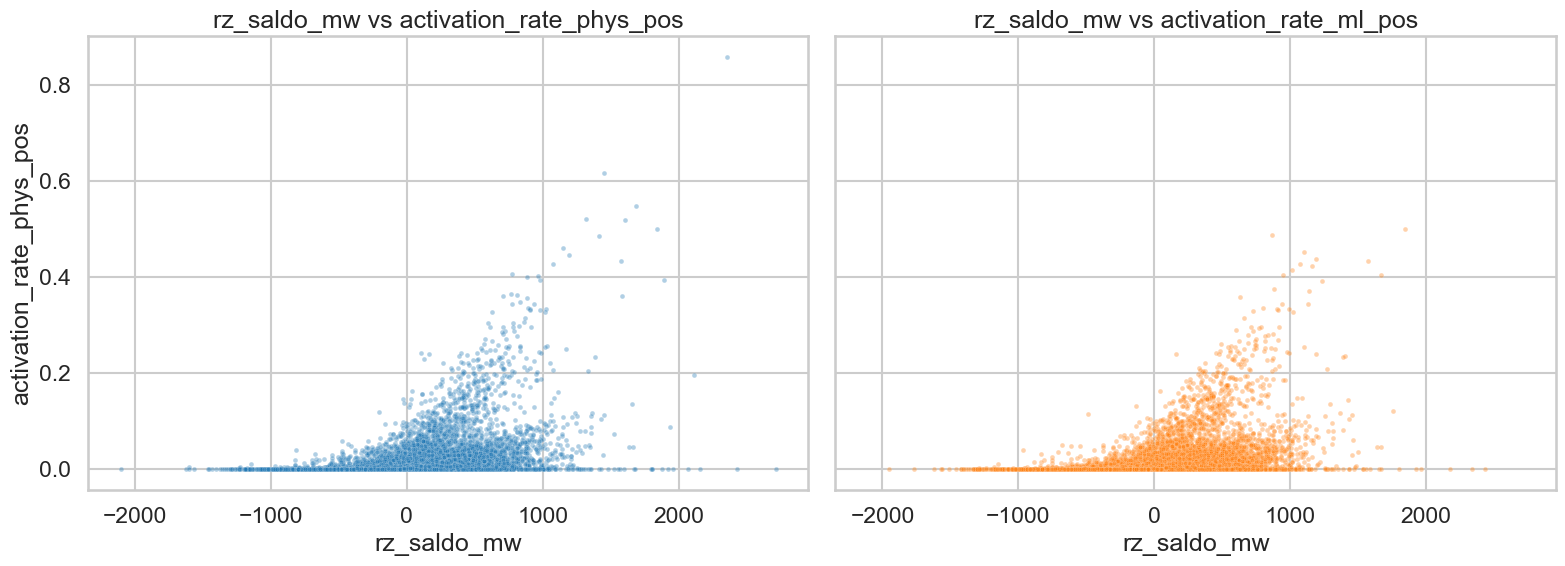

In [8]:
corr_pdf = corr_base.to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

sns.scatterplot(
    data=corr_pdf.sample(min(12000, len(corr_pdf)), random_state=42),
    x='rz_saldo_mw',
    y='activation_rate_phys_pos',
    s=12,
    alpha=0.35,
    ax=axes[0],
    color='#1f77b4'
)
axes[0].set_title('rz_saldo_mw vs activation_rate_phys_pos')

sns.scatterplot(
    data=corr_pdf.sample(min(12000, len(corr_pdf)), random_state=43),
    x='rz_saldo_mw',
    y='activation_rate_ml_pos',
    s=12,
    alpha=0.35,
    ax=axes[1],
    color='#ff7f0e'
)
axes[1].set_title('rz_saldo_mw vs activation_rate_ml_pos')

plt.tight_layout()
plt.show()


**Conclusion (Section 3)**

Pearson correlation indicates whether both rate definitions increase with system stress (`rz_saldo_mw`). A weaker ML correlation can be expected due to capping at 1.0, which compresses high-stress tails.


## 4) 48h Time-Series Window with High Volatility
We select the 48h window with the highest cumulative absolute `rz_saldo_mw`.


In [9]:
window = (
    df.select([
        'timestamp_utc',
        pl.col('rz_saldo_mw').cast(pl.Float64, strict=False).abs().alias('rz_abs'),
        pl.col('activation_rate_phys_pos').cast(pl.Float64, strict=False).alias('activation_rate_phys_pos'),
        pl.col('activation_rate_ml_pos').cast(pl.Float64, strict=False).alias('activation_rate_ml_pos'),
    ])
    .with_columns(
        pl.col('rz_abs')
        .rolling_sum(window_size=48, min_periods=48)
        .alias('rz_abs_sum_48h')
    )
)

peak_row = (
    window
    .drop_nulls(['rz_abs_sum_48h'])
    .sort('rz_abs_sum_48h', descending=True)
    .select('timestamp_utc')
    .head(1)
)

if peak_row.height == 0:
    raise ValueError('Could not identify a 48h volatility window.')

end_ts = peak_row.item()
start_ts = end_ts - pd.Timedelta(hours=47)

w48 = (
    window
    .filter((pl.col('timestamp_utc') >= pl.lit(start_ts)) & (pl.col('timestamp_utc') <= pl.lit(end_ts)))
    .sort('timestamp_utc')
)

print('Selected 48h window:', start_ts, '->', end_ts)


Selected 48h window: 2022-06-18 15:00:00+00:00 -> 2022-06-20 14:00:00+00:00


/var/folders/mh/98qk5jbj4z336rv06wpgxbz40000gn/T/ipykernel_24944/807060883.py:10: DeprecationWarning: the argument `min_periods` for `Expr.rolling_sum` is deprecated. It was renamed to `min_samples` in version 1.21.0.
  .rolling_sum(window_size=48, min_periods=48)


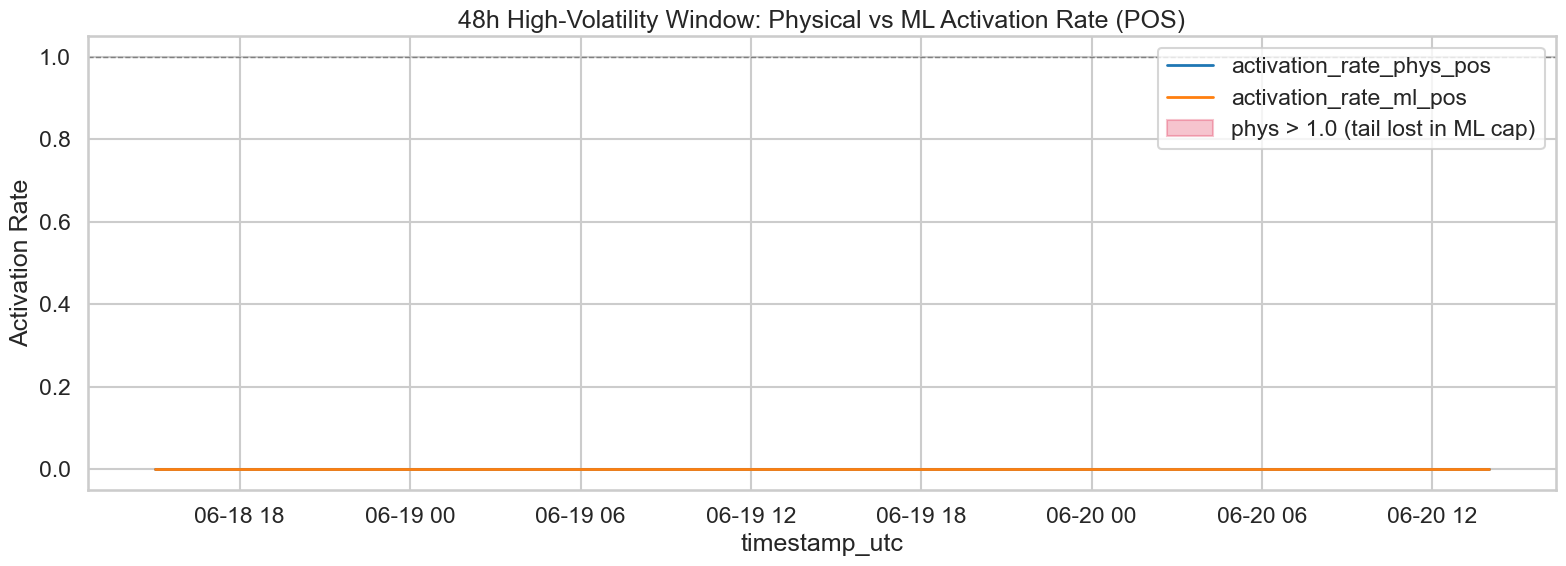

In [10]:
w48_pd = w48.select([
    'timestamp_utc',
    'activation_rate_phys_pos',
    'activation_rate_ml_pos',
]).to_pandas()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(w48_pd['timestamp_utc'], w48_pd['activation_rate_phys_pos'], label='activation_rate_phys_pos', color='#1f77b4', lw=2)
ax.plot(w48_pd['timestamp_utc'], w48_pd['activation_rate_ml_pos'], label='activation_rate_ml_pos', color='#ff7f0e', lw=2)

# Highlight where physical rate exceeds 1.0 (information not preserved in ML cap)
phys_vals = w48_pd['activation_rate_phys_pos'].to_numpy(dtype=float)
ax.fill_between(
    w48_pd['timestamp_utc'],
    1.0,
    phys_vals,
    where=np.isfinite(phys_vals) & (phys_vals > 1.0),
    color='crimson',
    alpha=0.25,
    label='phys > 1.0 (tail lost in ML cap)'
)

ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
ax.set_title('48h High-Volatility Window: Physical vs ML Activation Rate (POS)')
ax.set_ylabel('Activation Rate')
ax.set_xlabel('timestamp_utc')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


**Conclusion (Section 4)**

In volatile windows, `activation_rate_phys_pos` can exceed 1.0 and preserves operational stress information for physically consistent SoC updates. `activation_rate_ml_pos` intentionally truncates these tails at 1.0, improving training robustness while sacrificing scarcity amplitude.
